In [47]:
import pandas as pd 
from matplotlib import pyplot as plt 

In [26]:
df = pd.read_csv('/Users/avinashladdha/___PERSONAL/Finance/stock_data/kp/analysis_results.csv')

In [29]:
df['Start_Date'] = pd.to_datetime(df['Start_Date'], format='%d/%m/%y')
df['End_Date'] = pd.to_datetime(df['End_Date'], format='%d/%m/%y')

df['Start_Month']= df['Start_Date'].dt.month
df['End_Month']= df['End_Date'].dt.month

In [31]:
# Filtering 

df_filtered = df[(df['Increased_25_pct'] == "Yes")]
df_filtered = df_filtered[(df_filtered['In_2020'] == "No")]
df_filtered = df_filtered.sort_values(by=['Symbol','Start_Date','End_Date'], ascending=True)
df_filtered = df_filtered.drop_duplicates(subset=['Symbol','Start_Month','End_Month'], keep='first') 

In [36]:
df_filtered.to_csv('/Users/avinashladdha/___PERSONAL/Finance/stock_data/kp/analysis_results_filtered.csv', index=False)

In [37]:
df_filtered.head()

,Symbol,Increased_25_pct,Start_Date,End_Date,Percentage_Change,In_2020,Start_Month,End_Month
55611,360ONE,Yes,2021-01-18,2021-07-19,34.80%,No,1,7
55620,360ONE,Yes,2021-02-01,2021-08-02,40.94%,No,2,8
55640,360ONE,Yes,2021-03-01,2021-08-30,35.98%,No,3,8
55644,360ONE,Yes,2021-03-05,2021-09-01,38.14%,No,3,9
55661,360ONE,Yes,2021-04-06,2021-10-04,25.61%,No,4,10


In [38]:
# The analysis_results_filtered is used to get next 9mnth and 12 mnth high using calculate_future_returns.py


In [45]:
df_filtered = pd.read_csv('/Users/avinashladdha/___PERSONAL/Finance/stock_data/kp/analysis_results_with_future.csv')

Text(0, 0.5, '% of Stocks')

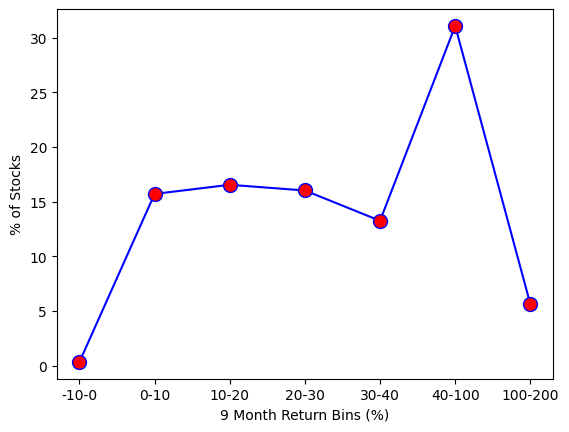

In [71]:
bins = [-10, 0, 10, 20, 30, 40,100,200]
labels = ['-10-0', '0-10', '10-20', '20-30', '30-40','40-100','100-200']
df_filtered['9_mth_ret_bins'] = pd.cut(df_filtered['Increase_9m_Pct'], bins=bins, labels=labels)

temp = 100*df_filtered.value_counts('9_mth_ret_bins').sort_index()/len(df_filtered)
plt.plot(temp,marker='o', linestyle='-', color='b', markersize=10, markerfacecolor='red')
plt.xlabel('9 Month Return Bins (%)')
plt.ylabel('% of Stocks')

Text(0, 0.5, '% of Stocks')

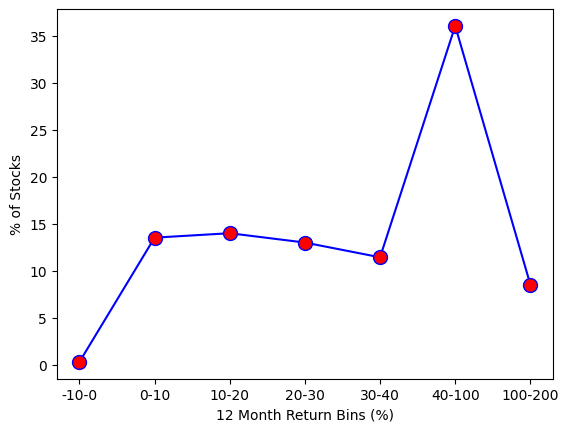

In [72]:
bins = [-10, 0, 10, 20, 30, 40,100,200]
labels = ['-10-0', '0-10', '10-20', '20-30', '30-40','40-100','100-200']
df_filtered['12_mth_ret_bins'] = pd.cut(df_filtered['Increase_12m_Pct'], bins=bins, labels=labels)

temp = 100*df_filtered.value_counts('12_mth_ret_bins').sort_index()/len(df_filtered)
plt.plot(temp,marker='o', linestyle='-', color='b', markersize=10, markerfacecolor='red')
plt.xlabel('12 Month Return Bins (%)')
plt.ylabel('% of Stocks')